In [25]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import sinter
import pickle

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode
from src.decoders import BPOSD

In [26]:
import stim

circ = stim.Circuit()
circ.append('R', [0, 1])
# circ.append('X_ERROR', 0, 0.1)
# circ.append('X_ERROR', 0, 0.11)
# circ.append('X_ERROR', 0, 0.111)
circ.append('H', 0)
circ.append('X_ERROR', 0, 0.1)
circ.append('H', 1)
circ.append('X', 1)
circ.append('X_ERROR', 1, 0.1)
circ.append('CX', [0, 1])
circ.append('X_ERROR', 0, 0.1)
circ.append('M', 0)
circ.append('X_ERROR', 1, 0.1)
circ.append('M', 1)
circ.append('DETECTOR', stim.target_rec(-1))
circ.append('R', [0, 1])
# circ.append('X_ERROR', 0, 0.1)
# circ.append('X_ERROR', 0, 0.11)
# circ.append('X_ERROR', 0, 0.111)
circ.append('H', 0)
circ.append('X_ERROR', 0, 0.1)
circ.append('H', 1)
circ.append('X', 1)
circ.append('X_ERROR', 1, 0.1)
circ.append('CX', [0, 1])
circ.append('X_ERROR', 0, 0.1)
circ.append('M', 0)
circ.append('X_ERROR', 1, 0.1)
circ.append('M', 1)

In [27]:
circ

stim.Circuit('''
    R 0 1
    H 0
    X_ERROR(0.1) 0
    H 1
    X 1
    X_ERROR(0.1) 1
    CX 0 1
    X_ERROR(0.1) 0
    M 0
    X_ERROR(0.1) 1
    M 1
    DETECTOR rec[-1]
    R 0 1
    H 0
    X_ERROR(0.1) 0
    H 1
    X 1
    X_ERROR(0.1) 1
    CX 0 1
    X_ERROR(0.1) 0
    M 0
    X_ERROR(0.1) 1
    M 1
''')

23 23


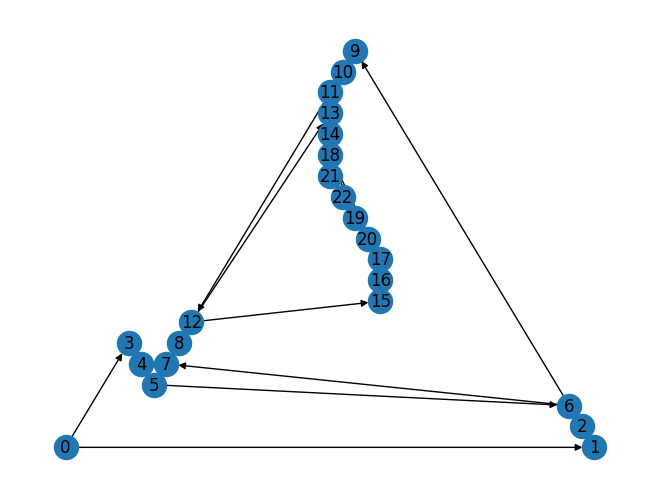

In [28]:
dag = device.circ_dag(circ)
print(len(dag.nodes), len(circ))
nx.draw_planar(dag, with_labels=True)

In [29]:
list(nx.topological_generations(dag))

[[0],
 [1, 3],
 [2, 4],
 [5],
 [6],
 [7, 9],
 [8, 10],
 [11],
 [12],
 [13, 15],
 [14, 16],
 [17],
 [18],
 [19, 21],
 [20, 22]]

In [30]:
print(device.simplify_stim_circuit(circ))

Reduced circuit length from 23 to 19

Looping. Current circuit length 19...
MERGING instructions [6, 8]
6 M 0
8 M 1

Looping. Current circuit length 15...
R 0 1
H 0 1
X 1
X_ERROR(0.1) 0 1
CX 0 1
X_ERROR(0.1) 0 1
M 0 1
DETECTOR rec[-1]
R 0 1
H 0 1
X 1
X_ERROR(0.1) 0 1
CX 0 1
X_ERROR(0.1) 0 1
M 0 1


In [31]:
compile_schedules = False
if compile_schedules:
    rs = [3,4,5]
    schedules = {}
    for r in rs:
        code_hgp = HGPCode.simplex_code(r=r)
        hwp = device.default_hwp

        num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
        s = int(np.sqrt(len(code_hgp.data_indices)//2))
        available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
        data_coords_hgp = {}
        for i,d in enumerate(code_hgp.data_indices):
            # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
            # data_coords_hgp[d] = coords
            # available_coords.remove(coords)
            if d < s**2:
                data_coords_hgp[d] = (d//s+1, d%s+1)
            else:
                dd = d-s**2
                data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

        dev = device.UnitCellDevice(2*s+2, s+2, hwp)

        sched = dev.compile_QEC_schedule(
            code_hgp,
            data_coords_hgp,
            [],
            rounds=code_hgp.compute_code_parameters()[2],
            use_highways=True,
            refocus_shuttle_noise=False,
            optimize_ancilla_start=True,
            separate_X_Z=True
        )
        schedules[r] = sched

    with open('notebooks/data/simplex_schedules.pkl', 'wb') as f:
        pickle.dump(schedules, f)
else:
    with open('notebooks/data/simplex_schedules.pkl', 'rb') as f:
        schedules = pickle.load(f)

In [32]:
compile_schedules = False
if compile_schedules:
    rs = [3,4,5]
    schedules_refoc = {}
    for r in rs:
        code_hgp = HGPCode.simplex_code(r=r)
        hwp = device.default_hwp

        num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
        s = int(np.sqrt(len(code_hgp.data_indices)//2))
        available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
        data_coords_hgp = {}
        for i,d in enumerate(code_hgp.data_indices):
            # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
            # data_coords_hgp[d] = coords
            # available_coords.remove(coords)
            if d < s**2:
                data_coords_hgp[d] = (d//s+1, d%s+1)
            else:
                dd = d-s**2
                data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

        dev = device.UnitCellDevice(2*s+2, s+2, hwp)

        sched = dev.compile_QEC_schedule(
            code_hgp,
            data_coords_hgp,
            [],
            rounds=code_hgp.compute_code_parameters()[2],
            use_highways=True,
            refocus_shuttle_noise=True,
            optimize_ancilla_start=True,
            separate_X_Z=True
        )
        schedules_refoc[r] = sched

    with open('notebooks/data/simplex_schedules_refoc.pkl', 'wb') as f:
        pickle.dump(schedules_refoc, f)
else:
    with open('notebooks/data/simplex_schedules_refoc.pkl', 'rb') as f:
        schedules_refoc = pickle.load(f)

In [33]:
circ = schedules[3].to_stim_circuit(HGPCode.simplex_code(3), 'X', device.error_params())

Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...


In [34]:
dag = device.circ_dag(circ)

In [35]:
print(circ)

R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
X_ERROR(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
H 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
DEPOLARIZE1(0.001) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 

In [36]:
len(circ)

13104

In [13]:
circ_simplified = device.simplify_stim_circuit(circ)

Reduced circuit length from 13104 to 11284

Looping. Current circuit length 11284...
MERGING instructions [0, 5, 159, 161, 163, 165, 167, 169, 171, 173, 175, 221, 223, 264, 422, 466, 472, 502, 516, 585, 697, 732, 818, 823, 871, 889, 899, 955, 1013, 1146, 1269, 1274, 1363, 1395, 1451, 1558, 1718, 1855, 1968]
0 R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
5 R 167 121 191 105 102 119 163 132 99 188 120 122 100 139 130 156 146 104 153 138 152 149 126 127 129 140 123 137 177 128 181 101 103 176 175 112 169 113 110 134 184 141 98 107 135 114 115 133 145 171 118 106 142 108
159 R 131
161 R 157 158
163 R 124 144
165 R 143
167 R 172 165 164 116
169 R 136
171 R 125
173 R 111
175 R 109
221 R 173 160
223 R 166
264 R 174
422 R 187
466 R 185
472 R 178
502 R 193
5

IndexError: list index out of range

In [ ]:
len(circ), len(device.simplify_stim_circuit(circ))

MERGING instructions [0, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 270, 273, 276, 279, 281, 284, 287, 289, 291, 295, 298, 301, 304, 307, 354, 356, 359, 409, 585, 645, 650, 682, 694, 778, 917, 954, 1049, 1056, 1105, 1122, 1140, 1210, 1214, 1276, 1411, 1539, 1547, 1659, 1697, 1763, 1883, 2056, 2204, 2318]
0 R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97
5 R 167
7 R 121
9 R 191
11 R 105
13 R 102
15 R 119
17 R 163
19 R 132
21 R 99
23 R 188
25 R 120
27 R 122
29 R 100
31 R 139
33 R 130
35 R 156
37 R 146
39 R 104
41 R 153
43 R 138
45 R 152
47 R 149
49 R 126
51 R 127
53 R 129
55 R 140


KeyboardInterrupt: 

In [ ]:
len(circ), len(device.simplify_stim_circuit(circ))

(13100, 11280)

In [38]:
generate_stim = True
if generate_stim:
    t2s = np.geomspace(100e-6, 10e-3, 7)
    rs_skip = [5]
    custom_decoders = {'bposd': BPOSD(
        max_iter=1000,
        bp_method='minimum_sum',
        ms_scaling_factor=0.625,
        osd_method='OSD_CS',
        osd_order=10,
    )}

    tasks = []
    for r,sched in schedules.items():
        if r in rs_skip:
            continue
        code_hgp = HGPCode.simplex_code(r=r)
        hwp = device.default_hwp

        num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
        s = int(np.sqrt(len(code_hgp.data_indices)//2))
        available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
        data_coords_hgp = {}
        for i,d in enumerate(code_hgp.data_indices):
            # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
            # data_coords_hgp[d] = coords
            # available_coords.remove(coords)
            if d < s**2:
                data_coords_hgp[d] = (d//s+1, d%s+1)
            else:
                dd = d-s**2
                data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

        dev = device.UnitCellDevice(2*s+2, s+2, hwp)

        for t2 in t2s:
            error_params = device.error_params(p=1e-3, T2=t2, p_sh=1e-5)
            tasks.append(
                sinter.Task(
                    circuit=sched.to_stim_circuit(code_hgp, 'X', error_params),
                    json_metadata={'r':r, 't2':t2, 'refoc': False}
                ))
            print(r, t2)
    for r,sched in schedules_refoc.items():
        if r in rs_skip:
            continue
        code_hgp = HGPCode.simplex_code(r=r)
        hwp = device.default_hwp

        num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
        s = int(np.sqrt(len(code_hgp.data_indices)//2))
        available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
        data_coords_hgp = {}
        for i,d in enumerate(code_hgp.data_indices):
            # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
            # data_coords_hgp[d] = coords
            # available_coords.remove(coords)
            if d < s**2:
                data_coords_hgp[d] = (d//s+1, d%s+1)
            else:
                dd = d-s**2
                data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

        dev = device.UnitCellDevice(2*s+2, s+2, hwp)

        for t2 in t2s:
            error_params = device.error_params(p=1e-3, T2=t2, p_sh=1e-5)
            tasks.append(
                sinter.Task(
                    circuit=sched.to_stim_circuit(code_hgp, 'X', error_params),
                    json_metadata={'r':r, 't2':t2, 'refoc': True}
                ))
            print(r, t2)
    with open('notebooks/data/simplex_stim_refoc.pkl', 'wb') as f:
        pickle.dump(tasks, f)
else:
    with open('notebooks/data/simplex_stim_refoc.pkl', 'rb') as f:
        tasks = pickle.load(f)

Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
3 0.0001
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
3 0.00021544346900318845
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
3 0.00046415888336127773
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
3 0.001
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
3 0.002154434690031882
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
3 0.004641588833612777
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
3 0.01
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
4 0.0001
Changing data qubit initialization to X basis...
Changing data qubit measurement to X basis...
4 0.000215443469

In [ ]:
# TODO: the issue is because we choose X basis (I think)

stats = sinter.collect(
    tasks=tasks,
    num_workers=6,
    decoders='bposd',
    custom_decoders=custom_decoders,
    max_shots=5*10**4,
    max_errors=100,
    print_progress=True,
    save_resume_filepath='notebooks/data/.tmp_sinter_progress',
)

Starting 6 workers...
28 tasks left:
  workers decoder eta shots_left errors_left json_metadata                            
        1   bposd   ?      50000         100 r=3,t2=0.0001,refoc=False                
        1   bposd   ?      50000         100 r=3,t2=0.00021544346900318845,refoc=False
        1   bposd   ?      50000         100 r=3,t2=0.00046415888336127773,refoc=False
        1   bposd   ?      50000         100 r=3,t2=0.001,refoc=False                 
        1   bposd   ?      50000         100 r=3,t2=0.002154434690031882,refoc=False  
        1   bposd 16m      49999         100 r=3,t2=0.004641588833612777,refoc=False  
        0   bposd ?·∞      50000         100 r=3,t2=0.01,refoc=False                  
        0   bposd ?·∞      50000         100 r=4,t2=0.0001,refoc=False                
        0   bposd ?·∞      50000         100 r=4,t2=0.00021544346900318845,refoc=False
        0   bposd ?·∞      50000         100 r=4,t2=0.00046415888336127773,refoc=False
      

Text(0, 0.5, 'LER')

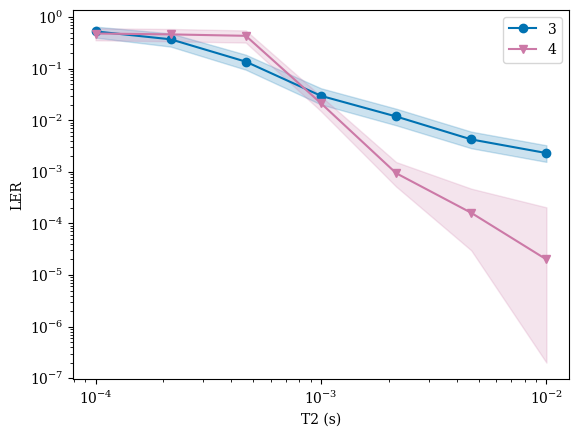

In [ ]:
fig,ax = plt.subplots()
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    group_func=lambda stats: stats.json_metadata['r'],
    x_func=lambda stats: stats.json_metadata['t2'],
)

plt.loglog()
plt.legend()
plt.xlabel('T2 (s)')
plt.ylabel('LER')